# MILK10k — Preprocessing: Normalization

Exploring normalization techniques and applying **min-max scaling** to all dataset images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [5]:
DATA_DIR = Path("../../milk10k_project")
image_paths = list((DATA_DIR / "images").glob("*.jpg"))
print(f"Found {len(image_paths)} images.")

Found 10480 images.


In [6]:
def min_max_normalize(image_array):
    """
    Scale an image array from [0, 255] to [0, 1] using min-max normalization.
    """
    return (image_array / 255.0).astype(np.float32)

Original range: [0, 230]
Normalized range: [0.0000, 0.9020]


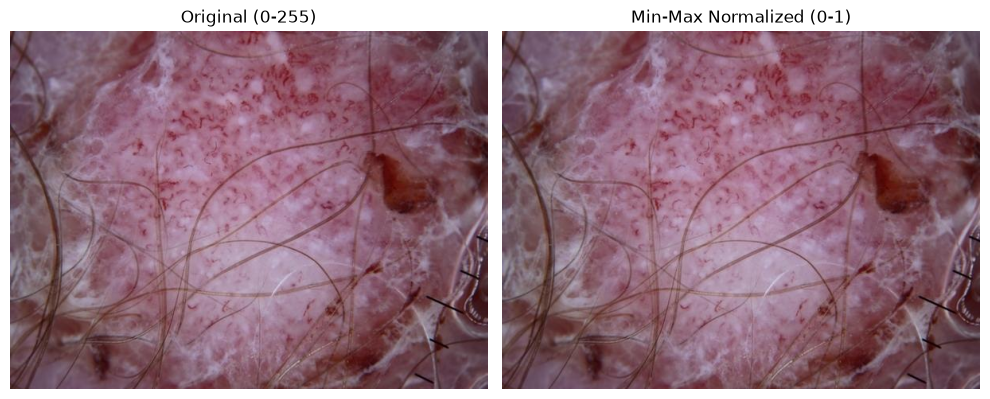

In [7]:
img = Image.open(image_paths[0])
img_array = np.array(img)

normalized = min_max_normalize(img_array)

print(f"Original range: [{img_array.min()}, {img_array.max()}]")
print(f"Normalized range: [{normalized.min():.4f}, {normalized.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_array)
axes[0].set_title("Original (0-255)")
axes[0].axis("off")
axes[1].imshow(normalized)
axes[1].set_title("Min-Max Normalized (0-1)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
def normalize_all_images(image_paths, limit=None):
    """
    Apply min-max normalization to all images found at image_paths.
    limit: process only the first N images (useful for testing).
    """
    normalized_images = []
    paths_to_process = image_paths[:limit] if limit else image_paths

    for i, path in enumerate(paths_to_process):
        img = Image.open(path).convert("RGB")
        img_array = np.array(img)
        normalized_images.append(min_max_normalize(img_array))

        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{len(paths_to_process)} images...")

    print(f"Done. Normalized {len(normalized_images)} images.")
    return normalized_images

In [9]:
normalized_sample = normalize_all_images(image_paths, limit=20)

print(f"Sample image shape: {normalized_sample[0].shape}")
print(f"Sample image dtype: {normalized_sample[0].dtype}")
print(f"Sample image range: [{normalized_sample[0].min():.4f}, {normalized_sample[0].max():.4f}]")

Done. Normalized 20 images.
Sample image shape: (450, 600, 3)
Sample image dtype: float32
Sample image range: [0.0000, 0.9020]
